# CNN Assignment
Based on Tensorflow tutorial https://www.tensorflow.org/tutorials/images/cnn?utm_source=chatgpt.com
Using https://www.kaggle.com/datasets/sharansmenon/animals141

# Resize
Resizes all images in the classes to (128*128) sizes

In [2]:
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

tf.random.set_seed(11)
DATA_DIR = "../data/cats"
IMG_SIZE = (128, 128)

ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=True,
    seed=42,
)
print(ds.class_names)

Found 257 files belonging to 7 classes.
['acinonyx-jubatus', 'felis-catus', 'panthera-leo', 'panthera-onca', 'panthera-pardus', 'panthera-tigris', 'puma-concolor']


# Show Before / After resize

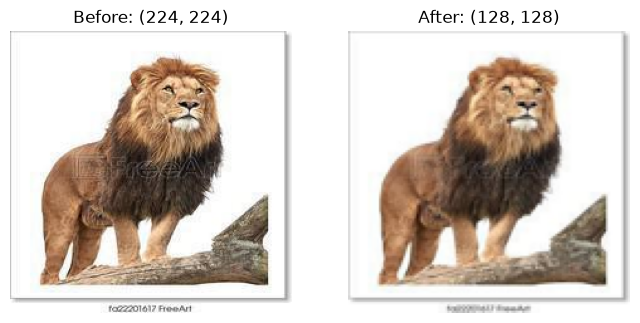

In [ ]:
img_path = next(Path(DATA_DIR, "panthera-leo").glob("*"))   # one lion image
orig = Image.open(img_path)
resized = orig.convert("RGB").resize(IMG_SIZE)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(orig);    ax[0].set_title(f"Before: {orig.size}")
ax[1].imshow(resized); ax[1].set_title(f"After: {resized.size}")
for a in ax: a.axis("off")
plt.savefig("../images/before_after_resize.png", bbox_inches="tight")
plt.show()

# Class Counter
To count how many images we have per class

In [5]:
from pathlib import Path

for c in sorted(Path("../data/cats").iterdir()):
    if c.is_dir():
        print(c.name, len(list(c.glob("*"))))

acinonyx-jubatus 33
felis-catus 33
panthera-leo 47
panthera-onca 49
panthera-pardus 34
panthera-tigris 28
puma-concolor 33


# Splitting
Selected split 70/15/15 from 275 images, so 
1. 180 Train
2. 39 Validation
3. 38 Test

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split

all_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=257,
    shuffle=False,
)
class_names = all_ds.class_names
images, labels = next(iter(all_ds))
x = images.numpy() #input
y = labels.numpy() #answers

# Splitting
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.30, stratify=y, random_state=11
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=11
)

# Shape gives (N, W, H, layers), not only like .count
print("Shapes:", x_train.shape, x_val.shape, x_test.shape)
for name, arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(name, np.bincount(arr, minlength=7))

Found 257 files belonging to 7 classes.
Shapes: (179, 128, 128, 3) (39, 128, 128, 3) (39, 128, 128, 3)
train [23 23 33 34 24 19 23]
val [5 5 7 8 5 4 5]
test [5 5 7 7 5 5 5]
